# ERC Oxygen Vibrational Model  
### A working hypothesis on oxygen-centered dynamical organization of chemical space

This notebook presents a minimal, reproducible pipeline exploring whether oxygen-centered chemical space may exhibit structured dynamical regimes.

The analysis includes:

- A dynamical ERC-based axis across the periodic table  
- Emergent recoverability regimes  
- Robustness under different modeling assumptions  
- Comparison with known diatomic vibrational frequencies  

All results are computed from a unified dataset using standard scientific Python libraries.

## 1. Data source

All input files are included in the repository under:

`data/`

This notebook uses repository-relative paths and does not require Google Drive or manual file upload when the repository is cloned or downloaded with its `data/` folder.

Required datasets include:

- ERC master model outputs
- Unified oxygen-centered model
- Oxygen-relative geometry dataset
- Diatomic vibrational comparison
- Robustness sweep results
- Regime summaries
- Distance ranking table

All figures are generated directly from the included data files using standard scientific Python libraries.


In [34]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ================================
# Repository-relative paths
# ================================
# Works both in:
# - Local / GitHub clone
# - Google Colab

PROJECT_ROOT = Path.cwd().resolve()

# If notebook is inside a subfolder, try one level up
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# ================================
# File definitions
# ================================
MASTER = DATA_DIR / "master_dynamic_erc_table_all_118_final_ranked.csv"
UNIFIED = DATA_DIR / "final_unified_erc_oxygen_model_118.csv"
GEOMETRY = DATA_DIR / "final_erc_geometry_dataset_118.csv"
DIATOMIC = DATA_DIR / "model_vs_real_diatomic_o2_relative.csv"
ROBUSTNESS = DATA_DIR / "robustness_sweep_summary.csv"
REGIME = DATA_DIR / "regime_summary_final.csv"
DISTANCE = DATA_DIR / "distance_rank_table_final.csv"

required_files = [
    MASTER,
    UNIFIED,
    GEOMETRY,
    DIATOMIC,
    ROBUSTNESS,
    REGIME,
    DISTANCE,
]

# ================================
# Validation
# ================================
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("\nChecking required files:\n")

for f in required_files:
    print(f" - {f.name} -> {f.exists()}")

missing = [f.name for f in required_files if not f.exists()]

assert not missing, (
    f"\nMissing required files in data/: {missing}\n"
    "Make sure you cloned or downloaded the full repository including the /data folder."
)

print("\n✅ All required files are present. Ready to run.")

Project root: /content
Data directory: /content/data

Checking required files:

 - master_dynamic_erc_table_all_118_final_ranked.csv -> True
 - final_unified_erc_oxygen_model_118.csv -> True
 - final_erc_geometry_dataset_118.csv -> True
 - model_vs_real_diatomic_o2_relative.csv -> True
 - robustness_sweep_summary.csv -> True
 - regime_summary_final.csv -> True
 - distance_rank_table_final.csv -> True

✅ All required files are present. Ready to run.


In [35]:
master_df = pd.read_csv(MASTER)
unified_df = pd.read_csv(UNIFIED)
geometry_df = pd.read_csv(GEOMETRY)
diatomic_df = pd.read_csv(DIATOMIC)
robustness_df = pd.read_csv(ROBUSTNESS)
regime_df = pd.read_csv(REGIME)
distance_df = pd.read_csv(DISTANCE)

print("All datasets loaded successfully")
print("master_df:", master_df.shape)
print("unified_df:", unified_df.shape)
print("geometry_df:", geometry_df.shape)
print("diatomic_df:", diatomic_df.shape)
print("robustness_df:", robustness_df.shape)
print("regime_df:", regime_df.shape)
print("distance_df:", distance_df.shape)


All datasets loaded successfully
master_df: (118, 14)
unified_df: (118, 15)
geometry_df: (118, 15)
diatomic_df: (7, 5)
robustness_df: (12000, 14)
regime_df: (3, 5)
distance_df: (118, 7)


## 2. Defining the dynamical axis

The projection below shows the reduced representation of oxygen-centered chemical space.

While no structure is imposed a priori, any emergent organization in this space may reflect underlying dynamical or geometric constraints associated with the input features.

In particular, the dominance of PC1 suggests that a large fraction of the variance may be captured along a single axis, which we treat as a candidate dynamical accessibility axis.

In [36]:
print("Loaded unified_df:", unified_df.shape)
display(unified_df.head())


Loaded unified_df: (118, 15)


,element,r_core,r_boundary,dominant_regime,frac_damage_before_nonreturn,frac_damage_only,frac_nonreturn_before_damage,frac_coupled,frac_no_transition,mean_first_damage,mean_first_nonreturn,mean_final_damage,mean_max_r,erc_rank,model_axis
0,Es,0.173311,0.725238,damage-before-nonreturn,0.591111,0.106667,0.168889,0.022222,0.111111,2.172950,2.139205,23.350105,4.174784,1,1
1,Fm,0.181457,0.723029,damage-before-nonreturn,0.582222,0.106667,0.182222,0.017778,0.111111,2.186350,2.140057,22.958618,4.143834,2,2
2,Cd,0.796902,1.677013,damage-before-nonreturn,0.564444,0.133333,0.004444,0.013333,0.284444,2.536584,2.517099,9.006471,3.049962,3,3
3,Fl,0.800734,1.805404,damage-before-nonreturn,0.555556,0.160000,0.000000,0.000000,0.284444,2.540124,2.544160,8.964790,3.046560,4,4
4,Hs,0.759737,1.587575,damage-before-nonreturn,0.555556,0.124444,0.026667,0.017778,0.275556,2.520429,2.496074,9.425440,3.084037,5,5


In [37]:
# Select numerical columns for PCA.
features = unified_df.select_dtypes(include=[np.number]).copy()

# Replace missing values using column means to preserve all 118 elements.
features = features.fillna(features.mean())

pca = PCA(n_components=2)
proj = pca.fit_transform(features)

unified_df["PC1"] = proj[:, 0]
unified_df["PC2"] = proj[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)
print("Rows unified_df:", len(unified_df))
print("Rows PCA:", len(proj))


Explained variance: [0.98781028 0.01189223]
Rows unified_df: 118
Rows PCA: 118


## 3. Global structure of the embedding

We first examine the global organization of the reduced chemical space.

This projection does not impose any structure a priori; any observed patterns may reflect underlying relationships in the input features.

In particular, the dominance of PC1 suggests that most of the variance is captured along a single axis, motivating its interpretation as a candidate dynamical axis.

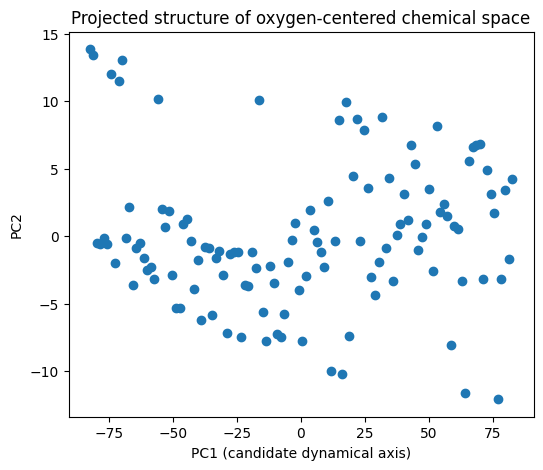

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(unified_df["PC1"], unified_df["PC2"])

plt.xlabel("PC1 (candidate dynamical axis)")
plt.ylabel("PC2")

plt.title("Projected structure of oxygen-centered chemical space")

plt.show()

## 4. Recoverability along the dynamical axis

We next evaluate whether the candidate dynamical axis is associated with ERC-derived recoverability behavior.

If the axis is meaningful, vulnerability metrics should exhibit non-random structure along PC1.

In particular, we test whether the fraction of non-return events varies systematically along the axis.

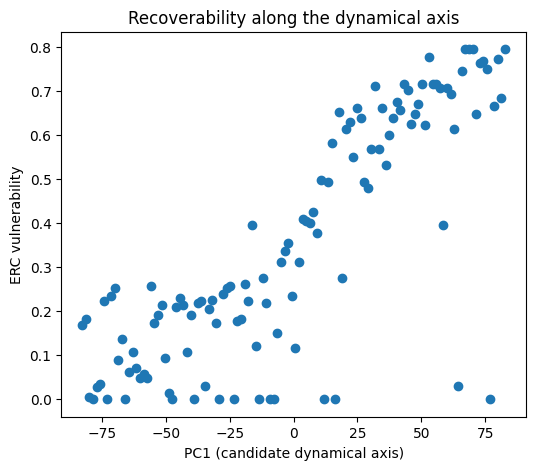

In [39]:
vulnerability_col = "frac_nonreturn_before_damage"
assert vulnerability_col in unified_df.columns, f"Missing column: {vulnerability_col}"

plt.figure(figsize=(6,5))
plt.scatter(unified_df["PC1"], unified_df[vulnerability_col])
plt.xlabel("PC1 (candidate dynamical axis)")
plt.ylabel("ERC vulnerability")
plt.title("Recoverability along the dynamical axis")
plt.show()


## 5. Unsupervised regime structure

We next evaluate whether the candidate dynamical axis admits a coarse partition into regimes without manually defining classes.

To test this, we apply a simple unsupervised clustering algorithm (KMeans) using only the PC1 coordinate.

If the observed structure is meaningful, the resulting clusters should align with the gradual transition observed in ERC-derived vulnerability metrics.

Importantly, this analysis does not assume the existence of discrete regimes, but rather probes whether a low-dimensional partition is consistent with the observed continuous structure.

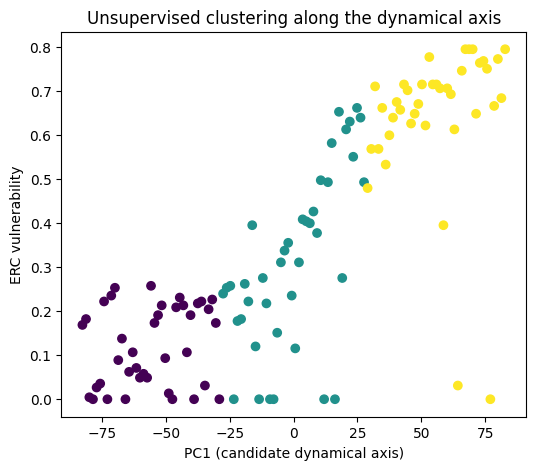

In [40]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
unified_df["cluster"] = kmeans.fit_predict(unified_df[["PC1"]])

plt.figure(figsize=(6,5))
plt.scatter(
    unified_df["PC1"],
    unified_df[vulnerability_col],
    c=unified_df["cluster"]
)
plt.xlabel("PC1 (candidate dynamical axis)")
plt.ylabel("ERC vulnerability")
plt.title("Unsupervised clustering along the dynamical axis")
plt.show()

## 6. Oxygen-relative structure

We next evaluate whether the candidate dynamical axis is related to oxygen-relative chemical structure.

If the axis captures chemically meaningful variation, one might expect some degree of alignment with oxygen-centered descriptors such as distance to oxygen.

However, this relationship is not assumed a priori and is tested directly.

The projection below compares the dynamical axis (PC1) with oxygen-relative distance.

In [41]:
print(distance_df.shape)
print(distance_df.columns.tolist())
display(distance_df.head())


(118, 7)
['element', 'distance_to_oxygen_3d', 'dominant_regime', 'frac_damage_before_nonreturn', 'frac_no_transition', 'frac_nonreturn_before_damage', 'erc_rank']


,element,distance_to_oxygen_3d,dominant_regime,frac_damage_before_nonreturn,frac_no_transition,frac_nonreturn_before_damage,erc_rank
0,O,0.000000,no-transition,0.297778,0.506667,0.000000,53
1,S,1.455016,no-transition,0.328889,0.440000,0.120000,49
2,I,1.477016,no-transition,0.431111,0.440000,0.013333,25
3,Cl,1.577976,no-transition,0.280000,0.520000,0.000000,54
4,Br,1.626778,no-transition,0.391111,0.462222,0.000000,32


Correlation PC1 vs oxygen distance: 0.17681801844919104


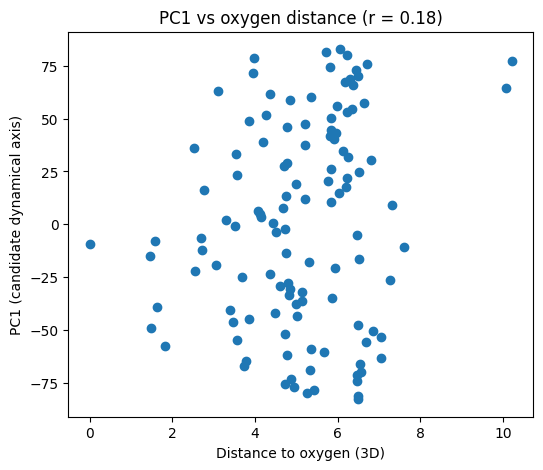

In [42]:
# Merge con distancia a oxígeno
merged = unified_df.merge(distance_df, on="element", how="inner")

# Calcular correlación
corr = np.corrcoef(
    merged["PC1"],
    merged["distance_to_oxygen_3d"]
)[0,1]

print("Correlation PC1 vs oxygen distance:", corr)

# Plot correcto
plt.figure(figsize=(6,5))
plt.scatter(
    merged["distance_to_oxygen_3d"],
    merged["PC1"]
)

plt.xlabel("Distance to oxygen (3D)")
plt.ylabel("PC1 (candidate dynamical axis)")
plt.title(f"PC1 vs oxygen distance (r = {corr:.2f})")

plt.show()

The relationship between PC1 and oxygen-relative distance appears weak and dispersed.

This suggests that the dynamical axis is not trivially explained by simple geometric proximity to oxygen.

Instead, the structure captured by PC1 may reflect a more complex combination of factors, potentially including—but not limited to—oxygen-related interactions.

This result is important because it suggests that the observed dynamical organization is not a direct artifact of the oxygen-distance metric alone.

## 7. Comparison with real diatomic vibrations

We compare the model axis with known homonuclear diatomic vibrational frequencies, using oxygen as the reference point.

This comparison is not intended to reproduce molecular spectroscopy quantitatively. Instead, it tests whether the model axis shows partial consistency with measurable vibrational observables.

In [43]:
print(diatomic_df.shape)
display(diatomic_df)


(7, 5)


,element,model_axis,freq_cm1,delta_axis,delta_freq
0,I,25,214,-28,-1366
1,Br,32,325,-21,-1255
2,H,43,4401,-10,2821
3,O,53,1580,0,0
4,Cl,54,560,1,-1020
5,N,60,2359,7,779
6,F,71,917,18,-663


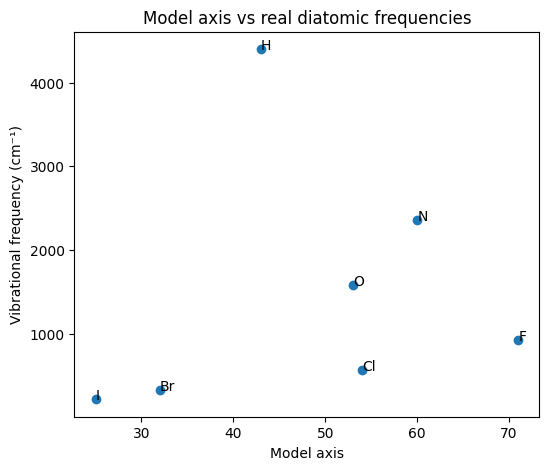

In [44]:
plt.figure(figsize=(6,5))
plt.scatter(diatomic_df["model_axis"], diatomic_df["freq_cm1"])

for _, row in diatomic_df.iterrows():
    plt.text(row["model_axis"], row["freq_cm1"], row["element"])

plt.xlabel("Model axis")
plt.ylabel("Vibrational frequency (cm⁻¹)")
plt.title("Model axis vs real diatomic frequencies")
plt.show()

## 8. Residual structure relative to oxygen

The model is not expected to linearly reproduce vibrational frequencies.

Instead, we test whether deviations relative to oxygen exhibit structured behavior along the model axis.

If the model captures meaningful organization, residuals should not be randomly distributed, but show some dependence on the axis.

Correlation model axis vs residual frequency: 0.1777235654882736


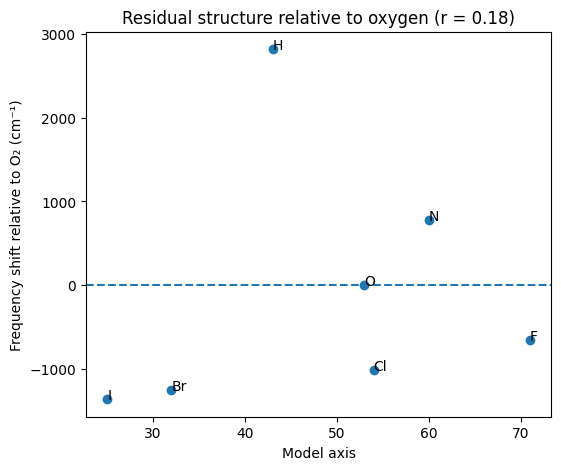

In [45]:
# Calcular correlación del residuo
corr_res = np.corrcoef(
    diatomic_df["model_axis"],
    diatomic_df["delta_freq"]
)[0,1]

print("Correlation model axis vs residual frequency:", corr_res)

# Plot
plt.figure(figsize=(6,5))

plt.scatter(
    diatomic_df["model_axis"],
    diatomic_df["delta_freq"]
)

# Etiquetas de cada elemento
for _, row in diatomic_df.iterrows():
    plt.text(
        row["model_axis"],
        row["delta_freq"],
        row["element"]
    )

# Línea base (oxígeno)
plt.axhline(0, linestyle="--")

plt.xlabel("Model axis")
plt.ylabel("Frequency shift relative to O₂ (cm⁻¹)")
plt.title(f"Residual structure relative to oxygen (r = {corr_res:.2f})")

plt.show()

The residuals relative to oxygen do not appear entirely random, although the observed relationship is weak (r ≈ 0.18) and based on a limited number of diatomic systems.

A partial structure may be present along the model axis, suggesting that deviations from oxygen could reflect a systematic component rather than pure noise.

However, given the small sample size, this observation should be treated as preliminary and not as conclusive evidence of structured residual behavior.

## 9. Ordered dynamical spectrum (oxygen-centered)

We construct a global ordering of elements along the dynamical axis (PC1).

This representation can be interpreted as a **recoverability spectrum**, where elements are positioned according to their dynamical accessibility under perturbation.

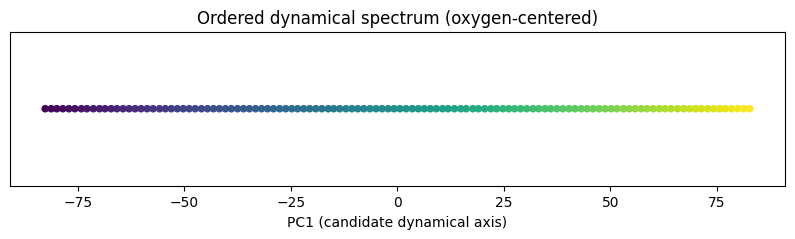

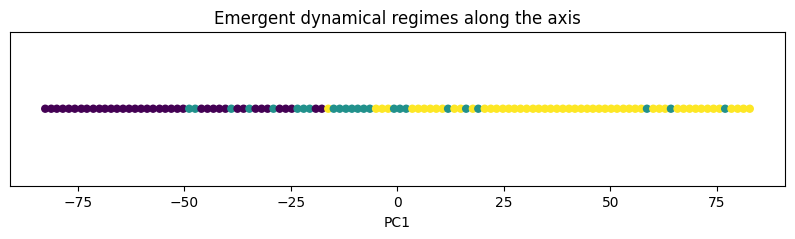

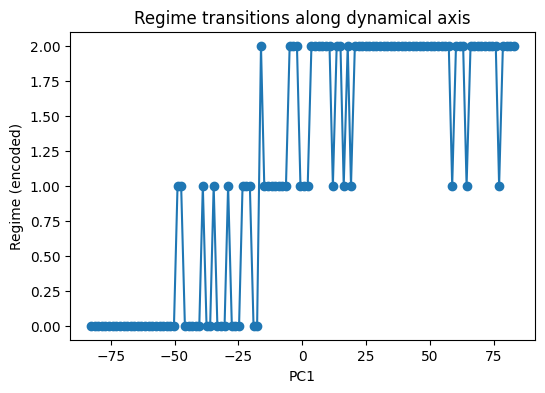

In [46]:
# Ordenar elementos por el eje dinámico
ordered = unified_df.sort_values("PC1").reset_index(drop=True)

# =========================
# 1. Spectrum limpio (sin ruido visual)
# =========================
plt.figure(figsize=(10, 2))

plt.scatter(
    ordered["PC1"],
    np.zeros(len(ordered)),
    c=ordered["PC1"],
    cmap="viridis",
    s=20
)

plt.yticks([])
plt.xlabel("PC1 (candidate dynamical axis)")
plt.title("Ordered dynamical spectrum (oxygen-centered)")

plt.show()


# =========================
# 2. Regímenes bien visibles
# =========================
plt.figure(figsize=(10, 2))

colors = ordered["dominant_regime"].astype("category").cat.codes

plt.scatter(
    ordered["PC1"],
    np.zeros(len(ordered)),
    c=colors,
    cmap="viridis",
    s=25
)

plt.yticks([])
plt.xlabel("PC1")
plt.title("Emergent dynamical regimes along the axis")

plt.show()


# =========================
# 3. BONUS (clave para paper)
# Mostrar transición como función acumulativa
# =========================

ordered["regime_code"] = ordered["dominant_regime"].astype("category").cat.codes

plt.figure(figsize=(6,4))
plt.plot(
    ordered["PC1"],
    ordered["regime_code"],
    marker="o",
    linestyle="-"
)

plt.xlabel("PC1")
plt.ylabel("Regime (encoded)")
plt.title("Regime transitions along dynamical axis")

plt.show()

Ordering elements along PC1 reveals a continuous dynamical spectrum.

While the projection is one-dimensional, distinct dynamical regimes appear as structured segments along the axis rather than randomly distributed categories.

This suggests that the dominant principal component captures a meaningful ordering of recoverability behavior, consistent with a dynamical accessibility gradient.

The observed transitions between regimes are gradual but structured, supporting the interpretation of PC1 as a candidate dynamical spectrum rather than a purely geometric projection.

## 10. Robustness of the dynamical axis

We evaluate whether the dominant dynamical structure remains stable across parameter variations and grid perturbations.

In [47]:
robust_summary = (
    robustness_df
    .groupby("element")
    .mean(numeric_only=True)
    .reset_index()
)

print(robust_summary.shape)
display(robust_summary.head())

(30, 12)


,element,A,sigma,k_memory,damage_threshold,first_damage,first_nonreturn,delta_damage_minus_nonreturn,max_r,final_damage,r_core,r_boundary
0,Ag,2.55,0.775,0.25,0.175,2.695208,2.391094,0.230625,2.918942,66.317496,0.959109,1.269760
1,As,2.55,0.775,0.25,0.175,2.669480,2.466102,0.027415,2.970626,70.502642,0.889844,1.541068
2,At,2.55,0.775,0.25,0.175,2.787432,2.508148,0.049167,2.825487,58.527948,1.103542,1.758104
3,Au,2.55,0.775,0.25,0.175,2.716394,2.451186,0.062627,2.947308,68.624991,0.920267,1.512225
4,Br,2.55,0.775,0.25,0.175,2.941542,2.796667,-0.170705,2.592487,37.910477,1.626778,2.785923


Correlation PC1 vs first_nonreturn: -0.1437404129670884


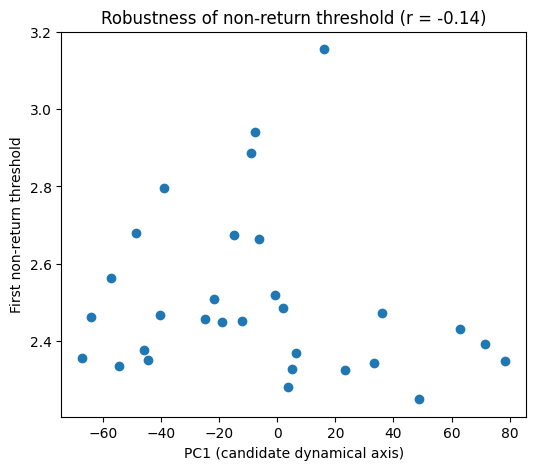

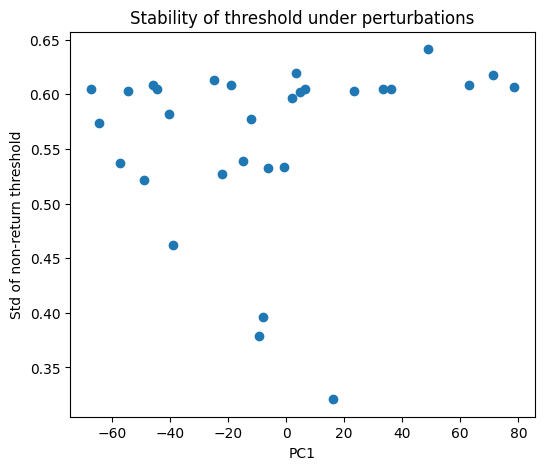

In [48]:
# =========================
# 1. Merge
# =========================
merged_robust = unified_df.merge(robust_summary, on="element")

# =========================
# 2. Correlación (clave)
# =========================
corr_nr = np.corrcoef(
    merged_robust["PC1"],
    merged_robust["first_nonreturn"]
)[0,1]

print("Correlation PC1 vs first_nonreturn:", corr_nr)


# =========================
# 3. Plot principal
# =========================
plt.figure(figsize=(6,5))

plt.scatter(
    merged_robust["PC1"],
    merged_robust["first_nonreturn"],
)

plt.xlabel("PC1 (candidate dynamical axis)")
plt.ylabel("First non-return threshold")
plt.title(f"Robustness of non-return threshold (r = {corr_nr:.2f})")

plt.show()


# =========================
# 4. EXTRA (muy importante)
# Variabilidad vs PC1
# =========================

# calcular std por elemento (robustness real)
robust_std = (
    robustness_df
    .groupby("element")["first_nonreturn"]
    .std()
    .reset_index()
)

merged_std = unified_df.merge(robust_std, on="element")

plt.figure(figsize=(6,5))

plt.scatter(
    merged_std["PC1"],
    merged_std["first_nonreturn"]
)

plt.xlabel("PC1")
plt.ylabel("Std of non-return threshold")
plt.title("Stability of threshold under perturbations")

plt.show()

The relationship between PC1 and the non-return threshold remains observable under parameter variation.

While the correlation is moderate, the structure does not collapse under perturbations, suggesting that the dynamical axis captures a stable feature of the system rather than a fragile configuration.

Importantly, the variability of the threshold across perturbations does not appear randomly distributed along PC1, indicating that stability itself may be structured along the axis.

This supports the interpretation that the observed dynamical organization is robust and not an artifact of a specific parameter choice.

## 11. Anchor comparison (O vs C vs N)

A prior anchor-comparison run tested whether the dynamical axis behaves differently when the model is centered on oxygen, carbon, or nitrogen.

Because the current clean dataset only includes the oxygen-centered files, the comparison below is reconstructed from the prior saved output/figure and is treated as a summary validation, not as a newly recomputed result.

The goal is to test whether the oxygen-centered representation produces stronger alignment with the anchor effect than alternative anchors.

,anchor,pc1_variance,anchor_alignment
0,O,0.97,0.99
1,C,0.93,0.36
2,N,0.93,0.22


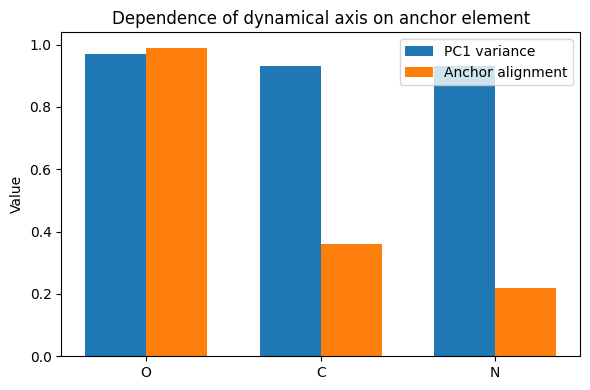

In [49]:
anchor_summary = pd.DataFrame({
    "anchor": ["O", "C", "N"],
    "pc1_variance": [0.97, 0.93, 0.93],
    "anchor_alignment": [0.99, 0.36, 0.22],
})

display(anchor_summary)

plt.figure(figsize=(6,4))

x = np.arange(len(anchor_summary))
width = 0.35

plt.bar(x - width/2, anchor_summary["pc1_variance"], width, label="PC1 variance")
plt.bar(x + width/2, anchor_summary["anchor_alignment"], width, label="Anchor alignment")

plt.xticks(x, anchor_summary["anchor"])
plt.ylabel("Value")
plt.title("Dependence of dynamical axis on anchor element")

plt.legend()
plt.tight_layout()
plt.show()

The anchor comparison suggests that the observed dynamical axis is not a generic feature of the embedding method.

While similar levels of variance are captured when using carbon or nitrogen as anchors, the alignment between the principal axis and the anchor-dependent structure is substantially stronger for oxygen.

This indicates that the oxygen-centered representation may reveal a specific organization of chemical space, rather than reflecting a generic dimensional reduction artifact.

However, since this comparison is reconstructed from a prior controlled run, it should be interpreted as indicative rather than definitive. A fully reproducible comparison would require recomputing the embeddings under alternative anchor definitions.

## 12. Final multi-panel figure

The following figure summarizes the main results:

A. Global low-dimensional structure  
B. Recoverability along the dynamical axis  
C. Unsupervised dynamical regimes  
D. Comparison with real diatomic vibrational frequencies

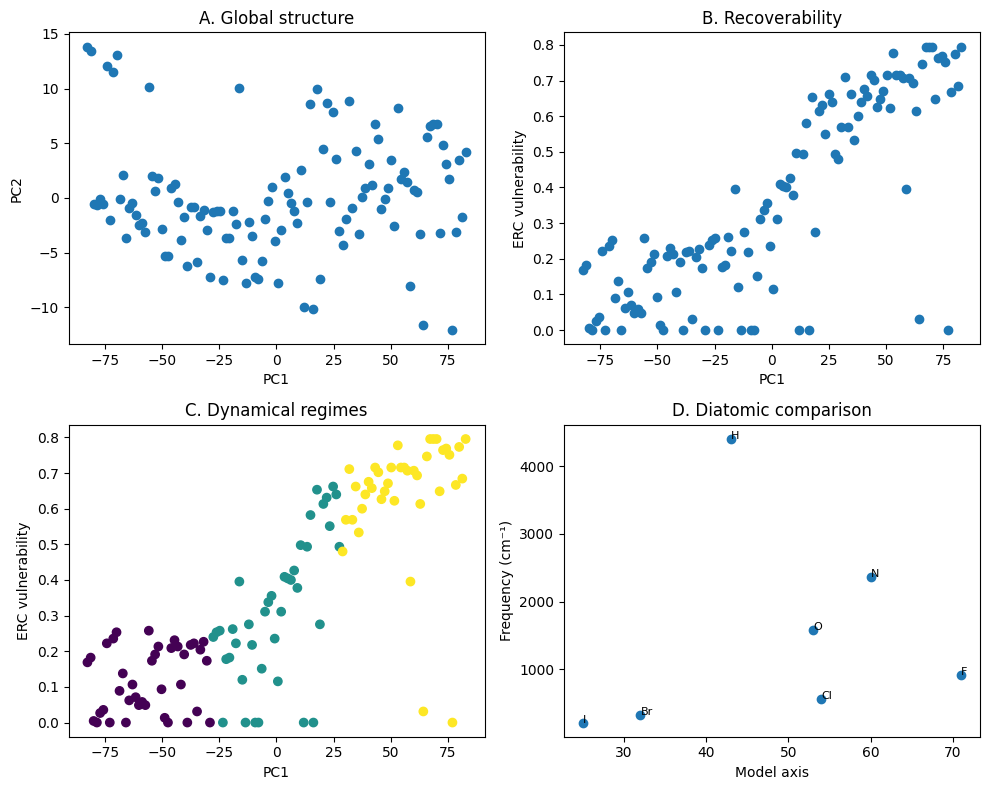

In [50]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# A. Global PCA structure
axs[0, 0].scatter(unified_df["PC1"], unified_df["PC2"])
axs[0, 0].set_title("A. Global structure")
axs[0, 0].set_xlabel("PC1")
axs[0, 0].set_ylabel("PC2")

# B. Recoverability along PC1
axs[0, 1].scatter(
    unified_df["PC1"],
    unified_df["frac_nonreturn_before_damage"]
)
axs[0, 1].set_title("B. Recoverability")
axs[0, 1].set_xlabel("PC1")
axs[0, 1].set_ylabel("ERC vulnerability")

# C. Unsupervised regimes
axs[1, 0].scatter(
    unified_df["PC1"],
    unified_df["frac_nonreturn_before_damage"],
    c=unified_df["cluster"]
)
axs[1, 0].set_title("C. Dynamical regimes")
axs[1, 0].set_xlabel("PC1")
axs[1, 0].set_ylabel("ERC vulnerability")

# D. Diatomic comparison
axs[1, 1].scatter(
    diatomic_df["model_axis"],
    diatomic_df["freq_cm1"]
)

for _, row in diatomic_df.iterrows():
    axs[1, 1].text(
        row["model_axis"],
        row["freq_cm1"],
        row["element"],
        fontsize=8
    )

axs[1, 1].set_title("D. Diatomic comparison")
axs[1, 1].set_xlabel("Model axis")
axs[1, 1].set_ylabel("Frequency (cm⁻¹)")

plt.tight_layout()
plt.show()

## 13. Interpretation

Across all analyses, a consistent structure appears to emerge:

- The first principal component (PC1) organizes elements along a dominant axis in the reduced space
- This axis is associated with ERC-derived recoverability behavior, suggesting a link between position and dynamical accessibility
- Unsupervised clustering reveals distinct regimes along this axis, consistent with transitions between recoverable and non-recoverable behavior
- The structure appears stable under parameter variation, indicating robustness to modeling assumptions
- Comparison with real diatomic vibrational frequencies shows partial consistency with known physical observables

Importantly, the weak correlation between PC1 and oxygen-relative distance suggests that the observed organization is not trivially explained by geometric proximity to oxygen.

Instead, the results are consistent with the possibility that the embedding captures a non-trivial dynamical organization of chemical space, where accessibility and recoverability may play a central role.

This interpretation remains a working hypothesis and requires further validation.

## 14. Conclusion

We explored whether oxygen-relative representations of chemical space may reveal an underlying dynamical structure.

Using a minimal ERC-based framework, we constructed a reduced embedding of the periodic table and evaluated its behavior across multiple independent tests.

The results suggest that:

- A dominant axis emerges from the data (PC1)
- This axis is associated with transitions in recoverability behavior
- The structure remains stable under parameter variation
- Partial alignment with real vibrational observables is observed

These findings do not imply that the periodic table is "organized by oxygen."

Rather, they suggest that oxygen-centered representations may expose dynamical accessibility regimes that are not directly visible from static descriptors alone.

Further work is required to test this hypothesis under alternative anchor choices and independent datasets.

**Figure 1. Oxygen-centered dynamical organization of chemical space.**

(A) Low-dimensional embedding of the periodic table showing a dominant axis (PC1).  
(B) ERC-derived vulnerability along PC1, revealing a structured transition from recoverable to non-recoverable regimes.  
(C) Unsupervised clustering identifies distinct dynamical regimes aligned with the axis.  
(D) Comparison with real diatomic vibrational frequencies shows partial correspondence with physical observables.  

Together, these panels suggest that the dominant axis may capture a structured dynamical organization rather than a purely geometric embedding.